In [56]:
 # Импорт библиотек
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn import decomposition
from sklearn import datasets

# Загрузка данных

In [57]:
 # Загрузка данных Ирисов
centers = [[1, 1], [-1, -1], [1, -1]]
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [58]:
X.shape, y.shape, iris.target_names

((150, 4), (150,), array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [59]:
# Создаем DataFrame для удобства работы
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df['numbers'] = iris.target

# Посмотрим на первые 5 строк датасета
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,numbers
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


# Первичный анализ

In [60]:
# Базовый статистический анализ
print(iris_df.describe())

# Проверка наличия пропущенных значений
print(iris_df.isnull().sum())

# Распределение классов
print(iris_df['species'].value_counts())

       sepal length (cm)  sepal width (cm)  ...  petal width (cm)     numbers
count         150.000000        150.000000  ...        150.000000  150.000000
mean            5.843333          3.057333  ...          1.199333    1.000000
std             0.828066          0.435866  ...          0.762238    0.819232
min             4.300000          2.000000  ...          0.100000    0.000000
25%             5.100000          2.800000  ...          0.300000    0.000000
50%             5.800000          3.000000  ...          1.300000    1.000000
75%             6.400000          3.300000  ...          1.800000    2.000000
max             7.900000          4.400000  ...          2.500000    2.000000

[8 rows x 5 columns]
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
numbers              0
dtype: int64
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [61]:
sns.set_theme(style="whitegrid")

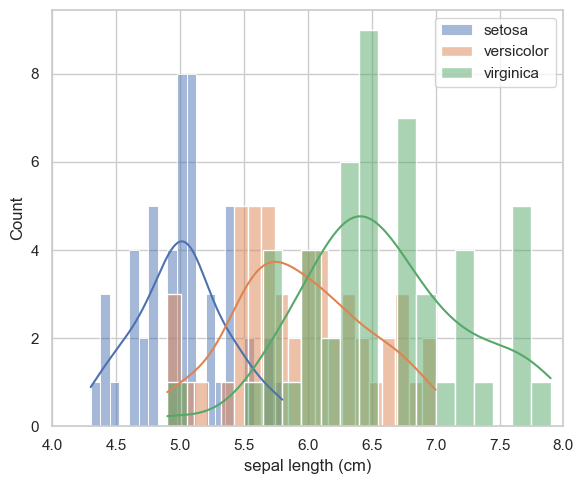

In [62]:
plt.figure(figsize=(6, 5))
plt.xlim((4, 8))
feature = iris.feature_names[0]

for species in iris.target_names:
    subset = iris_df[iris_df['species'] == species]
    sns.histplot(subset[feature], label=species, kde=True, bins=20)
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
plt.show()

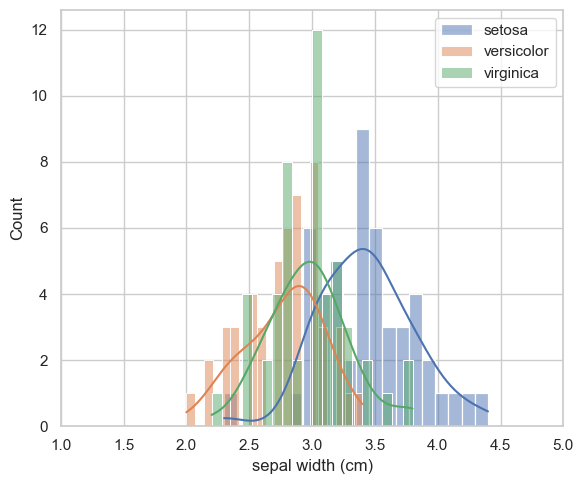

In [63]:
plt.figure(figsize=(6, 5))
plt.xlim((1, 5))
feature = iris.feature_names[1]

for species in iris.target_names:
    subset = iris_df[iris_df['species'] == species]
    sns.histplot(subset[feature], label=species, kde=True, bins=20)
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
plt.show()

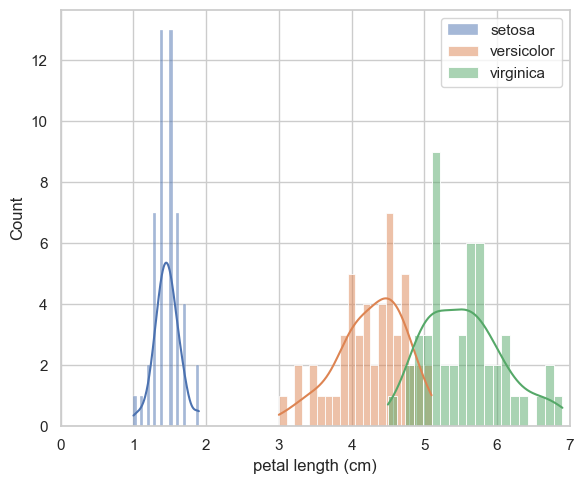

In [64]:
plt.figure(figsize=(6, 5))
plt.xlim((0, 7))
feature = iris.feature_names[2]

for species in iris.target_names:
    subset = iris_df[iris_df['species'] == species]
    sns.histplot(subset[feature], label=species, kde=True, bins=20)
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
plt.show()

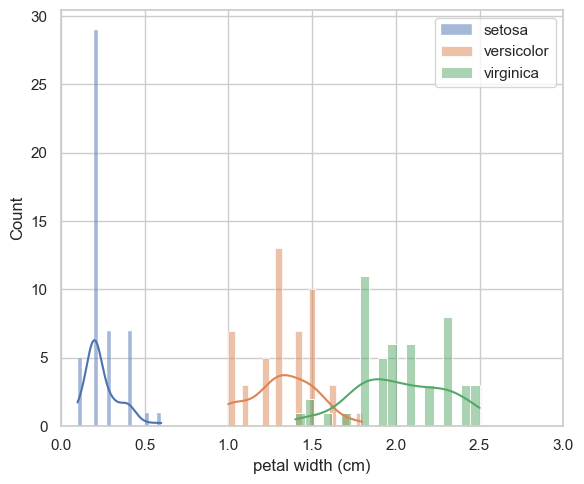

In [65]:
plt.figure(figsize=(6, 5))
plt.xlim((0, 3))
feature = iris.feature_names[3]

for species in iris.target_names:
    subset = iris_df[iris_df['species'] == species]
    sns.histplot(subset[feature], label=species, kde=True, bins=20)
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
plt.show()

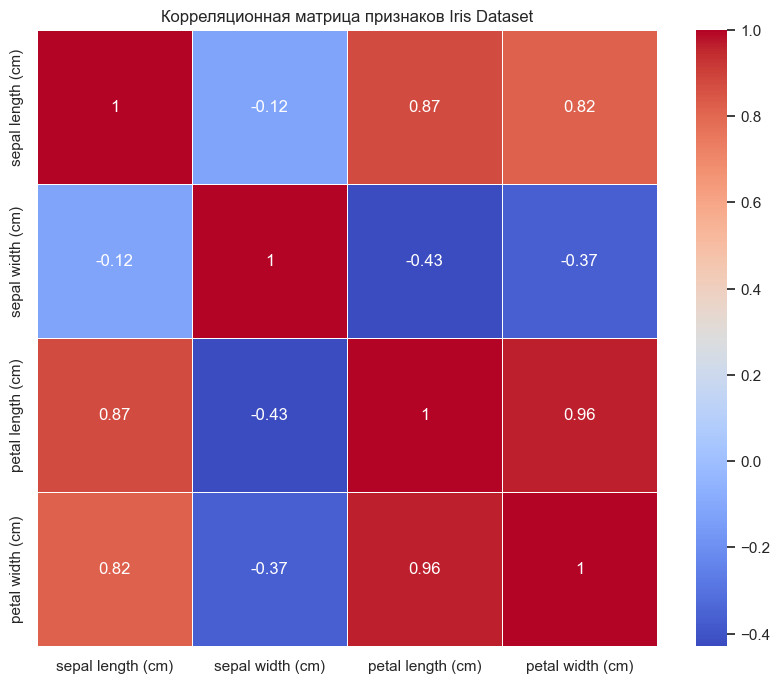

In [66]:
# Корреляционная тепловая карта
plt.figure(figsize=(10, 8))
iris_df.drop('numbers', axis=1, inplace=True)
corr = iris_df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Корреляционная матрица признаков Iris Dataset")
plt.show()

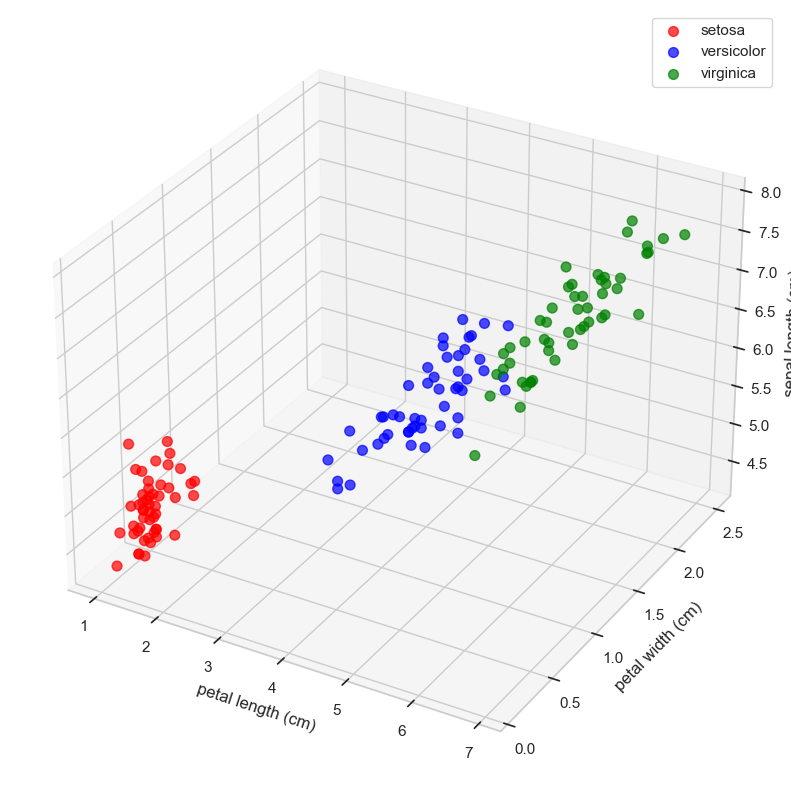

In [67]:
# 3D визуализация
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Выбираем три наиболее информативных признака
x = iris_df['petal length (cm)']
y = iris_df['petal width (cm)']
z = iris_df['sepal length (cm)']

# Цвета для разных классов
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

# Наносим точки на график
for species in iris.target_names:
  idx = iris_df['species'] == species
  ax.scatter(x[idx], y[idx], z[idx], c=colors[species], label=species, s=50, alpha=0.7)

ax.set_xlabel('petal length (cm)')
ax.set_ylabel('petal width (cm)')
ax.set_zlabel('sepal length (cm)')
ax.legend()
plt.show()

# Обучение модели

Разобьем данные на тренировочный и тестовый датасеты и для простоты реализации алгоритма объединим массивы признаков объектов и метки их классов, чтобы было понятно, к какому классу относится каждый объект.

In [68]:
SIZE = 40  # размер обучающей выборки

In [69]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(iris.data[:, [0,2,3]],
                                                    iris.target,
                                                    train_size=SIZE,
                                                    random_state=541) # random_state - для воспроизводимости

print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (40, 3), y_train shape: (40,),
X_test shape: (110, 3), y_test shape: (110,)


In [70]:
x_train_concat = np.concatenate((x_train, np.array(y_train).reshape(SIZE, 1)), axis=1)
x_test_concat = np.concatenate((x_test, np.array(y_test).reshape(150-SIZE, 1)), axis=1)
print(f'X_train shape: {x_train_concat.shape},\n'
      f'X_test shape: {x_test_concat.shape}')

X_train shape: (40, 4),
X_test shape: (110, 4)


Выбираем норму

$\lVert x \rVert_1 = \sum\limits_{i=1}^n \lvert x_i \rvert$ - Манхэттэнская норма

$\lVert x \rVert_2 = \sqrt{\sum\limits_{i=1}^n x_i^2}$ - Евклидова норма

$\lVert x \rVert_p = \sqrt[p]{\sum\limits_{i=1}^n x_i^p}$ - норма Минковского

$\lVert x \rVert_\infty = \max\limits_i \lvert x_i \rvert$ - норма Чебышева

In [71]:
norms = {"Манхэттэнская" : 1, "Евклидова" : 2, "Минковского" : 3, "Чебышева" : np.inf}


Вычислим расстояния до всех точек обучающей выборки и отберем  k  соседей (то есть тех, расстояния до которых минимальны).

In [72]:
def get_neighbors(train, test, norm, k=1):
    distances = [(train[i][-1], np.linalg.norm(train[i][:-1] - test[:-1], ord=norm))
                  for i in range (len(train))]
    distances.sort(key=lambda elem: elem[1])

    neighbors = [distances[i][0] for i in range (k)]
    return neighbors

Теперь получим прогноз на основе классов соседей. Посчитаем, сколько объектов каждого класса присутствует среди  k  ближайших к целевому, и затем причислим его к тому классу, экземпляров которого больше всего.

In [73]:
def prediction(neighbors):
    count = {}
    for instance in neighbors:
        if instance in count:
            count[instance] +=1
        else :
            count[instance] = 1
    target = max(count.items(), key=lambda x: x[1])[0]
    return target

Напишем последнюю функцию для оценки точности прогнозов - это просто отношение верных прогнозов к общему количеству прогнозов.

In [74]:
def accuracy(test, test_prediction):
    correct = 0
    for i in range (len(test)):
        if test[i][-1] == test_prediction[i]:
            correct += 1
    return (correct / len(test))

Посмотрим, как работает алгоритм.

In [75]:
predictions = []
for x in range (len(x_test_concat)):
    neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms['Евклидова'], k=5)
    result = prediction(neighbors)
    predictions.append(result)
acc = accuracy(x_test_concat, predictions)
print(f'Accuracy: {acc}')

Accuracy: 0.8909090909090909


импортируем библиотечную версию алгоритма.

In [76]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

In [77]:
knn_model = knn.fit(x_train, y_train)

In [78]:
knn_predictions = knn.predict(x_test)
knn_predictions

array([2, 0, 1, 0, 1, 1, 0, 1, 0, 2, 1, 1, 1, 0, 1, 1, 2, 2, 0, 0, 0, 0,
       2, 1, 1, 2, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 2, 1, 1, 2, 2, 1, 1,
       1, 0, 2, 1, 1, 1, 1, 2, 0, 0, 1, 1, 1, 1, 0, 1, 2, 0, 0, 2, 1, 1,
       0, 0, 2, 0, 0, 1, 0, 2, 1, 2, 2, 2, 0, 1, 0, 1, 2, 0, 1, 2, 0, 1,
       0, 0, 0, 0, 2, 0, 1, 0, 2, 1, 1, 1, 2, 0, 1, 0, 0, 2, 2, 0, 1, 1])

In [79]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, knn_predictions)
print(f'Accuracy: {acc}')

Accuracy: 0.8909090909090909


# Подбор параметров модели

In [80]:
mod_acc = []
for knbr in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=knbr)
    knn_model = knn.fit(x_train, y_train)
    knn_predictions = knn.predict(x_test)
    acc = accuracy_score(y_test, knn_predictions)
    mod_acc.append((knbr, acc))
lib_acc = np.array(mod_acc)

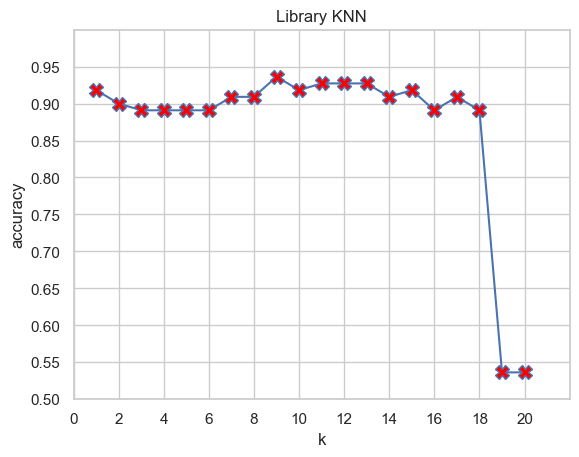

In [81]:
plt.plot(lib_acc[:, 0], lib_acc[:, 1], marker='X', markersize=10, markerfacecolor='red')
plt.title("Library KNN")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 2))
plt.yticks(np.arange(0.5, 1, 0.05))
plt.xlim((0, 22))
plt.ylim((0.5, 1))
plt.show()

In [82]:
res_acc = []
for knbr in range(1, 21):
    predictions = []
    for x in range (len(x_test_concat)):
        neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms['Евклидова'], k=knbr)
        result = prediction(neighbors)
        predictions.append(result)
    acc = accuracy(x_test_concat, predictions)
    res_acc.append([knbr, acc])
own_acc = np.array(res_acc)

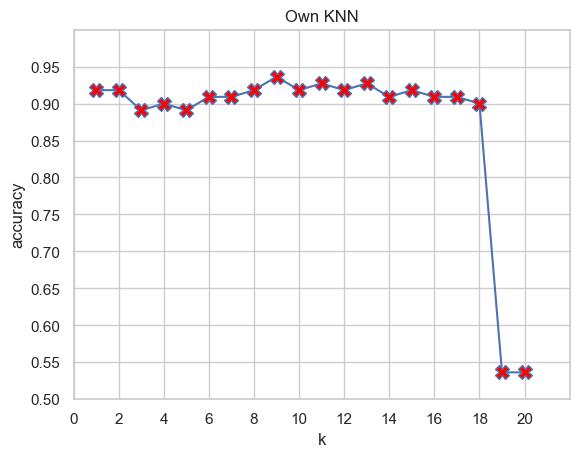

In [83]:
plt.plot(own_acc[:, 0], own_acc[:, 1], marker='X', markersize=10, markerfacecolor='red')
plt.title("Own KNN")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 2))
plt.yticks(np.arange(0.5, 1, 0.05))
plt.xlim((0, 22))
plt.ylim((0.5, 1))
plt.show()

In [84]:
metric_acc = pd.DataFrame()
for norm in norms:
    cur_acc = []
    for knbr in range(1, 21):
        predictions = []
        for x in range (len(x_test_concat)):
            neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms[norm], k=knbr)
            result = prediction(neighbors)
            predictions.append(result)
        acc = accuracy(x_test_concat, predictions)
        cur_acc.append(acc)
    metric_acc[norm] = cur_acc

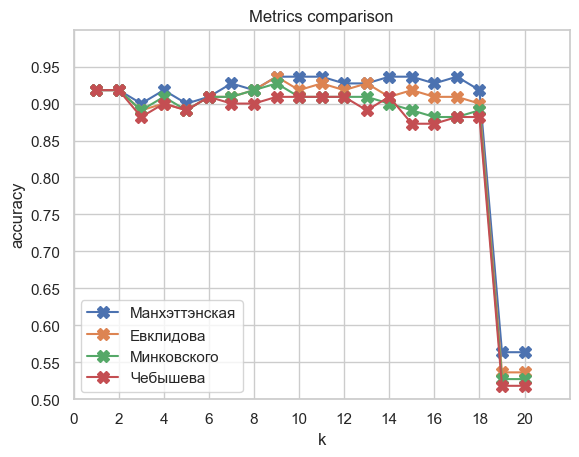

In [85]:
for norm in norms:
    plt.plot(range(1, 21), metric_acc[norm], marker='X', markersize=8, label=norm)
plt.legend()
plt.title("Metrics comparison")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 2))
plt.yticks(np.arange(0.5, 1, 0.05))
plt.xlim((0, 22))
plt.ylim((0.5, 1))
plt.show()

Составим матрицу путаницы

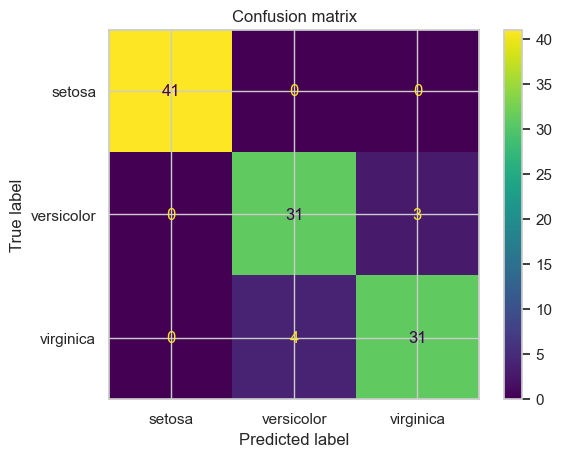

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(x_train, y_train)
cm = confusion_matrix(y_test, knn_model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Confusion matrix")
plt.show()

# PCA

## Преобразование

In [32]:
# Загрузка данных для PCA
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [33]:
res_eig = np.linalg.eig(np.dot(X.T, X))
print(*np.linalg.svd(np.dot(X.T, X)), sep='\n')

[[-0.75110816 -0.2841749   0.50215472  0.32081425]
 [-0.38008617 -0.5467445  -0.67524332 -0.31725607]
 [-0.51300886  0.70866455 -0.05916621 -0.48074507]
 [-0.16790754  0.34367081 -0.53701625  0.75187165]]
[9.20830507e+03 3.15454317e+02 1.19780429e+01 3.55257020e+00]
[[-0.75110816 -0.38008617 -0.51300886 -0.16790754]
 [-0.2841749  -0.5467445   0.70866455  0.34367081]
 [ 0.50215472 -0.67524332 -0.05916621 -0.53701625]
 [ 0.32081425 -0.31725607 -0.48074507  0.75187165]]


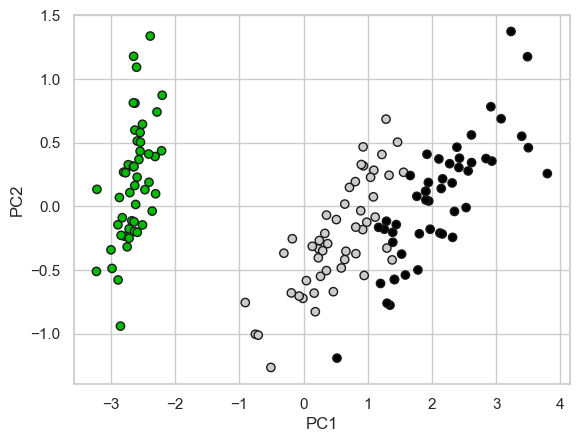

In [34]:
 # Преобразование данных датасета Iris, уменьшающее размерность до 2
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X = pca.transform(X)
y = np.choose(y, [1, 2, 0]).astype(np.float32)
plt.clf()
plt.cla()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.nipy_spectral, edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Обучение модели

In [35]:
from sklearn.model_selection import train_test_split

SIZE = 40

x_train, x_test, y_train, y_test = train_test_split(X[:, :],
                                                    y,
                                                    train_size=SIZE,
                                                    random_state=541) # random_state - для воспроизводимости

print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (40, 3), y_train shape: (40,),
X_test shape: (110, 3), y_test shape: (110,)


In [36]:
x_train_concat = np.concatenate((x_train, y_train.reshape(SIZE, 1)), axis=1)
x_test_concat = np.concatenate((x_test, y_test.reshape(150-SIZE, 1)), axis=1)
print(f'X_train shape: {x_train_concat.shape},\n'
      f'X_test shape: {x_test_concat.shape}')

X_train shape: (40, 4),
X_test shape: (110, 4)


In [37]:
pd.DataFrame(x_train_concat).head(5)

,0,1,2,3
0,0.588006,-0.484287,0.444433,2.0
1,2.159438,-0.217278,0.208763,0.0
2,0.045227,-0.583834,-0.235002,2.0
3,0.357888,-0.068925,-0.229854,2.0
4,0.464800,-0.670712,-0.024307,2.0


In [38]:
res_acc = []
for knbr in range(1, 21):
    predictions = []
    for x in range(len(x_test_concat)):
        neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms['Манхэттэнская'], k=knbr)
        result = prediction(neighbors)
        predictions.append(result)
    acc = accuracy(x_test_concat, predictions)
    res_acc.append([knbr, acc])
pca_acc = np.array(res_acc)

## Оценка обучения

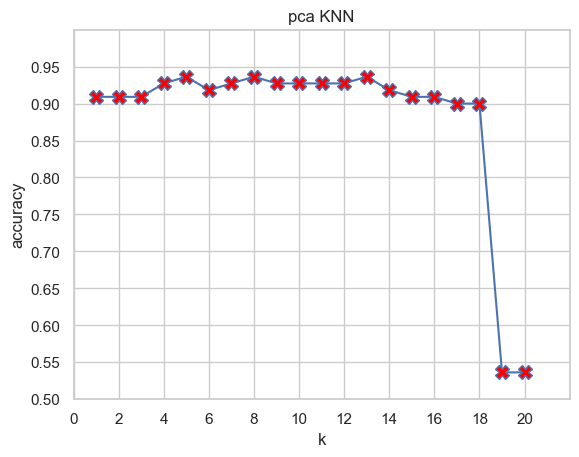

In [39]:
plt.plot(pca_acc[:, 0], pca_acc[:, 1], marker='X', markersize=10, markerfacecolor='red')
plt.title("pca KNN")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 2))
plt.yticks(np.arange(0.5, 1, 0.05))
plt.xlim((0, 22))
plt.ylim((0.5, 1))
plt.show()

In [40]:
np.mean(pca_acc, axis=0), np.mean(metric_acc['Манхэттэнская'])

(array([10.5       ,  0.88136364]), np.float64(0.8877272727272727))

In [41]:
mae_metr = 0
for k in range(1, 21):
    mae_metr += np.abs(metric_acc['Манхэттэнская'][k-1] - pca_acc[k-1][1])
mae_metr /= 20
print(mae_metr)

0.01545454545454547


# Сравнение с другими моделями

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(iris.data[:, [0, 2, 3]],
                                                    iris.target,
                                                    train_size=SIZE,
                                                    random_state=541
                                                    )
print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (40, 3), y_train shape: (40,),
X_test shape: (110, 3), y_test shape: (110,)


## Логистическая регрессия

In [48]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Случайное дерево

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## KNN

In [54]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train, Y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Сравнение accuracy

In [55]:
print("KNN:", accuracy_score(Y_test, knn_model.predict(X_test)))
print("Логистическая регрессия:", accuracy_score(Y_test, lr.predict(X_test)))
print("Случайное дерево:", accuracy_score(Y_test, rf.predict(X_test)))

KNN: 0.9363636363636364
Логистическая регрессия: 0.9
Случайное дерево: 0.9272727272727272
